One panel per month, where each shows a shaded gridded distribution map of the number of calyptopes or furcilia per grid cell in that month, and then overlay the trajectories for that month on those density distributions? That might illustrate the changes in distribution over time more clearly


I'm imagining being able to compare these maps with those that Frankie Perry et al. plotted from the observational data which I think would be neat. I don't know if overlaying the trajectories would obscure the underlying density data though...

If it worked, you could then repeat the plots for the other two years for Supp. Mat. so that interannual differences can be viewed.

In [22]:
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib import ticker

from matplotlib.patches import Rectangle
import importlib
import utils  # Importing the utils module

In [26]:
# Helper function to plot the base map and all boxes
def plot_region(ax, extent):
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, zorder=2)
    ax.add_feature(cfeature.LAND, facecolor='lightgrey', zorder=2)
    gl = ax.gridlines(draw_labels=False, linewidth=0.5, color='grey', alpha=0.5, linestyle='--', zorder=1)
    gl.xlocator = ticker.FixedLocator(range(-180, 181, 10))
    gl.ylocator = ticker.FixedLocator(range(-90, 91, 5))
    gl.xlabel_style = {'size': 10, 'color': 'gray'}
    gl.ylabel_style = {'size': 10, 'color': 'gray'}


In [4]:
# File Paths to data
repo_path = '/Users/zephyrsylvester/repos/circumpolar-connectivity-analysis/'
output_path = '/Users/zephyrsylvester/repos/circumpolar-connectivity-analysis/processed_data/'
fig_path = repo_path + 'figures/path-plots/'
tab_path = repo_path + 'figures/tables/'

summary_file = 'nursery_use_summary.csv'
start_file = 'IDLloc_spawning_21dfilter.csv'
traj_file = 'processed_trajectories_21dfilter.csv'

summary=pd.read_csv(output_path + summary_file) 

starting_location_df=pd.read_csv(output_path + start_file) 

df_traj=pd.read_csv(output_path + traj_file) 

## Bring in data

In [90]:
# Step 1: Preprocess the data with debugging
def preprocess_data(df, start_year, hypothesis, stage, lat_bins, lon_bins):
    # Filter by year, hypothesis, and stage
    subset_df = df[(df['start_year'] == start_year) & (df['hypothesis'] == hypothesis)]
    stage_df = subset_df[subset_df['stage'] == stage].copy()
    
    # Debug: Check if there's data after filtering
    if stage_df.empty:
        print(f"No data available after filtering for year {start_year}, hypothesis {hypothesis}, stage {stage}.")
        return {}
    # Convert longitudes from 0-360° to -180 to 180°
    stage_df['lon'] = stage_df['lon'].apply(lambda x: x - 360 if x > 180 else x)
    
    # Extract the month from the date column
    stage_df['month'] = pd.to_datetime(stage_df['date']).dt.month
    
    # Initialize a dictionary to store the heatmap for each month
    monthly_heatmaps = {}
    
    # Group data by month and calculate the heatmap for each month
    for month, month_df in stage_df.groupby('month'):
        print(f"Processing month {month} with {len(month_df)} data points")  # Debug: Check data points for each month
        
        # Initialize a heatmap grid with zeros for each month
        coarse_heatmap = np.zeros((len(lat_bins) - 1, len(lon_bins) - 1))
        
        # Bin the data points into the grid for the month
        for _, row in month_df.iterrows():
            lat_idx = np.digitize(row['lat'], lat_bins) - 1
            lon_idx = np.digitize(row['lon'], lon_bins) - 1
            
            # Debug: Check if the point is within the grid bounds
            if 0 <= lat_idx < len(lat_bins) - 1 and 0 <= lon_idx < len(lon_bins) - 1:
                coarse_heatmap[lat_idx, lon_idx] += 1
            else:
                print(f"Point ({row['lat']}, {row['lon']}) falls outside the grid bounds.")
        
        # Store the heatmap in the dictionary with the month as the key
        monthly_heatmaps[month] = coarse_heatmap
    
    return monthly_heatmaps


## Use Perry et al resolution: 1 ̊latitude by 2 ̊ longitude grid cells

In [15]:
from matplotlib.colors import LinearSegmentedColormap

perry_colors = ['#2892c6', '#6da9b3', '#9fc29a',
                '#cfde81', '#fafa64', '#fcc44d',
                '#fa8c33', '#f25822', '#e70f15' ]

# Create a custom colormap from your colors
perry_cmap = LinearSegmentedColormap.from_list("perry_colors", perry_colors)


In [82]:
importlib.reload(utils) # Run this if you update something in your utils file you need

# months = utils.months_data
# month_colors = {key: value['color'] for key, value in months.items()}
# month_labels = {key: value['label_long'] for key, value in months.items()}
# month_order = {key: value['order'] for key, value in months.items()}

# stages = utils.stages
# stage_colors = {key: value['color'] for key, value in stages.items()}
# stage_labels = {key: value['label'] for key, value in stages.items()}
# stage_markers = {key: value['marker'] for key, value in stages.items()}

# # Different Hypotheses (in this case only hi res)
# hypotheses = utils.hypotheses
# hypotheses_name = {key: value['name'] for key, value in hypotheses.items()}
# hypothesis_labels = {key: value['label'] for key, value in hypotheses.items()}
# hypothesis_order = {key: value['order'] for key, value in hypotheses.items()}


# Define a configuration dictionary
plot_config = {
    'month_labels': {key: value['label_long'] for key, value in utils.months_data.items()},
    'month_order': {key: value['order'] for key, value in utils.months_data.items()},
    'stage_labels': {key: value['label'] for key, value in utils.stages.items()},
    'hypothesis_labels': {key: value['label'] for key, value in utils.hypotheses.items()},
    'hypotheses_name': {key: value['name'] for key, value in utils.hypotheses.items()}
}
plot_config

{'month_labels': {1: 'January',
  2: 'February',
  3: 'March',
  4: 'April',
  5: 'May',
  6: 'June',
  7: 'July',
  8: 'August',
  9: 'September',
  10: 'October',
  11: 'November',
  12: 'December'},
 'month_order': {1: 3,
  2: 4,
  3: 5,
  4: 6,
  5: 7,
  6: 8,
  7: 9,
  8: 10,
  9: 11,
  10: 12,
  11: 1,
  12: 2},
 'stage_labels': {0: 'Embryo',
  1: 'Nauplii',
  2: 'Calyptopes',
  3: 'Furcilia I-III',
  4: 'Furcilia IV+'},
 'hypothesis_labels': {'h_null': 'Ocean',
  'h_ice': 'Ice',
  'h_dvm': 'DVM',
  'h_size': 'Size'},
 'hypotheses_name': {'h_null': 'h_null',
  'h_ice': 'h_ice',
  'h_dvm': 'h_dvm',
  'h_size': 'h_size'}}

In [16]:
# Define parameters for preprocessing
SY = 2018
hyp = 'h_ice'
age = 3 

# Define the grid extent and resolution (1° latitude by 2° longitude)
lat_min, lat_max = -75, -50
lon_min, lon_max = -90, 0
lat_resolution = 1  # 1 degree latitude resolution
lon_resolution = 2  # 2 degree longitude resolution

# Create latitude and longitude bins for the coarse grid
lat_bins = np.arange(lat_min, lat_max + lat_resolution, lat_resolution)
lon_bins = np.arange(lon_min, lon_max + lon_resolution, lon_resolution)

# Step 2: Preprocess the data and generate heatmaps for each month
monthly_heatmaps = preprocess_data(df_traj, start_year=SY, hypothesis=hyp, stage=age, lat_bins=lat_bins, lon_bins=lon_bins)

# Step 3: Inspect the heatmaps before plotting
if not monthly_heatmaps:
    print("No heatmaps were generated. Something went wrong during preprocessing.")
else:
    print("Available heatmaps:", monthly_heatmaps.keys())


Processing month 1 with 613 data points
Processing month 2 with 1134 data points
Processing month 3 with 1571 data points
Processing month 4 with 1622 data points
Processing month 5 with 2078 data points
Processing month 6 with 902 data points
Available heatmaps: dict_keys([1, 2, 3, 4, 5, 6])


In [19]:
# Step 4: Plot the heatmap for each month with your formatting
def plot_heatmap(coarse_heatmap_xr, coarse_heatmap, month, lat_bins, lon_bins, fig_path, SY, hyp, age):
    # Step 7: Plot the coarse grid heatmap over the base map
    fig, ax = plt.subplots(figsize=(10, 6), subplot_kw={'projection': ccrs.SouthPolarStereo()})
    extent = [270, 330, -63, -59]#[-85, -49, -72, -59]  # Adjust extent to -180 to 180 longitude format

    # Plot the base map with the region
    plot_region(ax, extent)

    # Set color scale limits for heatmap
    vmin = 0  # Minimum value
    vmax = 300  # Adjust based on your data

    # Overlay the heatmap using pcolormesh for proper alignment with lat/lon
    heatmap_plot = coarse_heatmap_xr.plot.pcolormesh(ax=ax, cmap=perry_cmap,
                                                     transform=ccrs.PlateCarree(),
                                                     vmin=vmin, vmax=vmax,
                                                     add_colorbar=True)

    # Outline grid cells where the values are greater than zero
    for lat_idx in range(len(lat_bins) - 1):
        for lon_idx in range(len(lon_bins) - 1):
            if coarse_heatmap[lat_idx, lon_idx] > 0:  # Only outline non-zero cells
                # Get the corners of the grid cell
                lon_start = lon_bins[lon_idx]
                lon_end = lon_bins[lon_idx + 1]
                lat_start = lat_bins[lat_idx]
                lat_end = lat_bins[lat_idx + 1]
                
                # Create a rectangle patch for the grid cell
                rect = Rectangle((lon_start, lat_start), lon_end - lon_start, lat_end - lat_start,
                                 linewidth=0.5, edgecolor='white', facecolor='none', zorder=3, 
                                 transform=ccrs.PlateCarree())  # Ensure it's added in lat/lon coordinates
                ax.add_patch(rect)

    # Add annotation text
    ax.text(0.41, 0.025,  # Coordinates in figure space (x, y)
        "1°lat by 2°lon grid from Perry et al. 2019", 
        transform=ax.transAxes,  # Use axis coordinates for positioning
        ha='center', va='center', fontsize=8, color='white')

    # Add title
    plt.title(f'Stage {age} Distribution for Month {month} ({SY})')

    # Save the plot before showing it
    save_path = f'{fig_path}/PERRYGRID_stage{age}_month{month}_year{SY}_{hyp}.png'
    plt.savefig(save_path, dpi=300, bbox_inches='tight')  # Save as a PNG with 300 DPI

    plt.show()


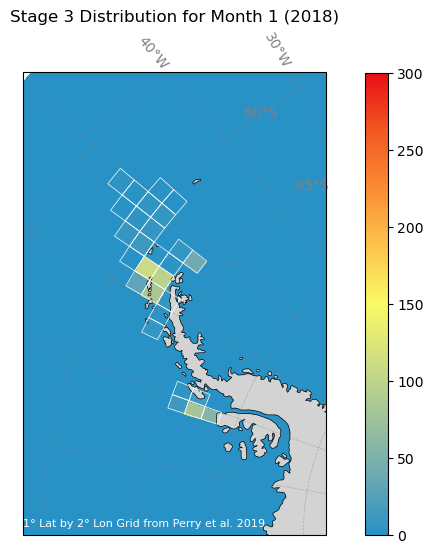

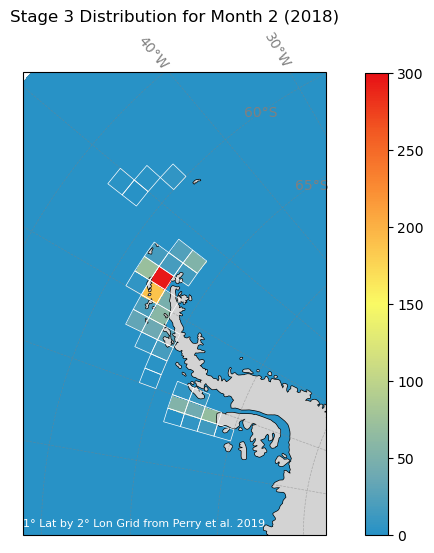

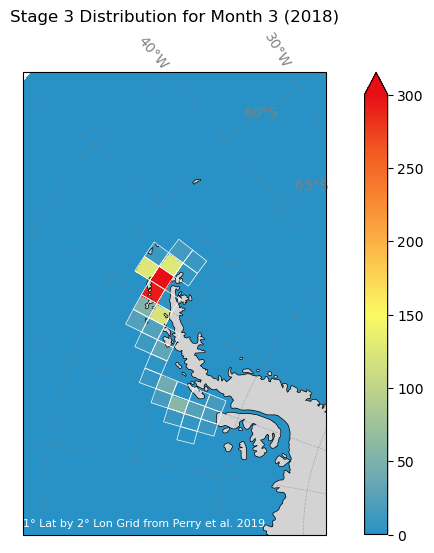

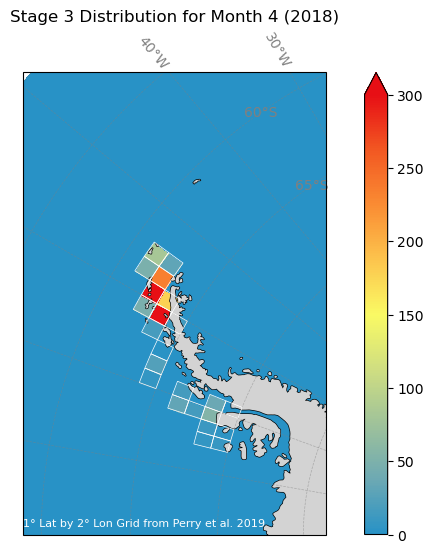

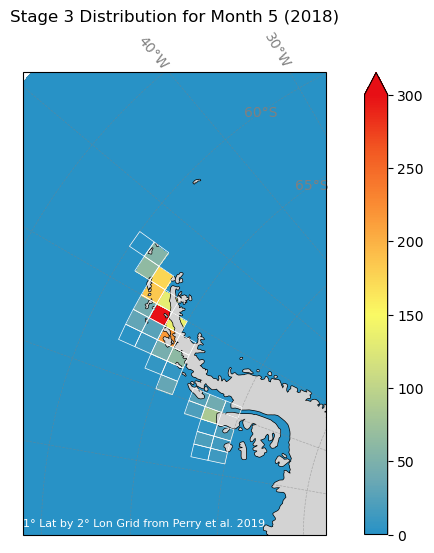

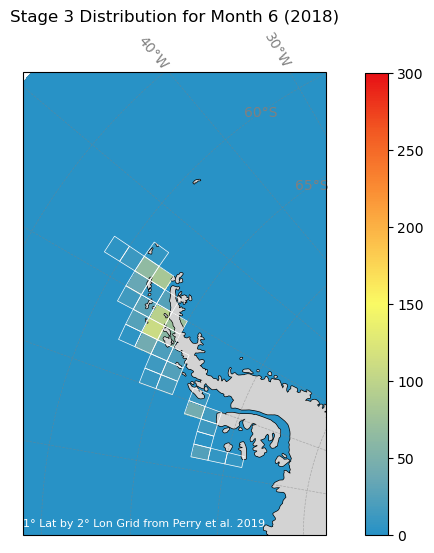

In [20]:
# Step 5: Loop through each month and plot with formatting
for month, heatmap in monthly_heatmaps.items():
    # Convert heatmap to xarray for plotting
    coarse_heatmap_xr = xr.DataArray(
        heatmap,
        coords=[('latitude', (lat_bins[:-1] + lat_bins[1:]) / 2),  # Midpoints of latitude bins
                ('longitude', (lon_bins[:-1] + lon_bins[1:]) / 2)],  # Midpoints of longitude bins
        dims=['latitude', 'longitude']
    )
    
    # Plot the heatmap for this month
    plot_heatmap(coarse_heatmap_xr, heatmap, month, lat_bins, lon_bins, fig_path, SY, hyp, age)

## Plot all the months

In [133]:
def plot_all_months(coarse_heatmaps, lat_bins, lon_bins, fig_path, SY, hyp, age, lat_resolution, lon_resolution, vmax, plot_config):
    # Extract information from the configuration dictionary
    month_labels = plot_config['month_labels']
    month_order = plot_config['month_order']
    stage_labels = plot_config['stage_labels']
    hypothesis_labels = plot_config['hypothesis_labels']
    
    # Filter out months where the heatmap has only zeros (no data)
    months_with_data = {month: heatmap for month, heatmap in coarse_heatmaps.items() if np.any(heatmap > 0)}
    
    # Sort the months with data according to their order
    months_sorted = sorted(months_with_data.keys(), key=lambda m: month_order[m])
    
    # Determine the number of subplots based on how many months have data
    num_months = len(months_sorted)
    num_cols = 4  # Number of columns in the grid (you can adjust this)
    num_rows = (num_months + num_cols - 1) // num_cols  # Calculate rows based on number of months with data
    
    # Create subplots grid
    fig, axs = plt.subplots(num_rows, num_cols, figsize=(18, 12), subplot_kw={'projection': ccrs.SouthPolarStereo()})
    
    # Flatten the array of axes to easily iterate
    axs = axs.flatten()

    # Set extent for all subplots (adjust extent to match your region)
    extent = [270, 330, -63, -59]
    
    # Iterate over each month and plot
    for i, month in enumerate(months_sorted):
        ax = axs[i]  # Current axis in the subplot grid
        
        # Plot the base map for the region
        plot_region(ax, extent)
        
        # Get the heatmap data for the current month
        coarse_heatmap = months_with_data[month]
        
        # Convert heatmap to xarray for plotting
        coarse_heatmap_xr = xr.DataArray(
            coarse_heatmap,
            coords=[('latitude', (lat_bins[:-1] + lat_bins[1:]) / 2),  # Midpoints of latitude bins
                    ('longitude', (lon_bins[:-1] + lon_bins[1:]) / 2)],  # Midpoints of longitude bins
            dims=['latitude', 'longitude']
        )
        
        # Set color scale limits for heatmap
        vmin = 0  # Minimum value
        vmax = vmax  # Adjust based on your data
        
        # Overlay the heatmap using pcolormesh for proper alignment with lat/lon
        heatmap_plot = coarse_heatmap_xr.plot.pcolormesh(ax=ax, cmap=perry_cmap,
                                                         transform=ccrs.PlateCarree(),
                                                         vmin=vmin, vmax=vmax,
                                                         add_colorbar=False)  # Add colorbar only to one axis
        
        # Outline grid cells where the values are greater than zero
        for lat_idx in range(len(lat_bins) - 1):
            for lon_idx in range(len(lon_bins) - 1):
                if coarse_heatmap[lat_idx, lon_idx] > 0:  # Only outline non-zero cells
                    # Get the corners of the grid cell
                    lon_start = lon_bins[lon_idx]
                    lon_end = lon_bins[lon_idx + 1]
                    lat_start = lat_bins[lat_idx]
                    lat_end = lat_bins[lat_idx + 1]
                    
                    # Create a rectangle patch for the grid cell
                    rect = Rectangle((lon_start, lat_start), lon_end - lon_start, lat_end - lat_start,
                                     linewidth=0.5, edgecolor='white', facecolor='none', zorder=3, 
                                     transform=ccrs.PlateCarree())  # Ensure it's added in lat/lon coordinates
                    ax.add_patch(rect)
        
        # Annotate with start year, hypothesis, and stage using labels and colors
        annotation_text = f"{stage_labels[age]}\n {month_labels[month]}"
        ax.text(0.025, .975, annotation_text, transform=ax.transAxes, fontsize=11, ha='left', va='top', color='white')

        # Annotate with start year, hypothesis, and stage using labels and colors
        annotation_text = f"Sim Year: {SY} \nSimulation: {hypothesis_labels[hyp]}"
        ax.text(0.025, .1, annotation_text, transform=ax.transAxes, fontsize=10, ha='left', va='top', color='white')

    # Hide any unused subplots
    for j in range(i+1, num_rows * num_cols):
        fig.delaxes(axs[j])
    
    # Add a common colorbar to the figure
    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  # Adjust colorbar position
    fig.colorbar(heatmap_plot, cax=cbar_ax)
    
    # Save the figure with the grid resolution in the filename
    save_path = f'{fig_path}/monthly-densities_{lat_resolution}Lat_{lon_resolution}Lon_year{SY}_{hyp}_stage{age}.png'
    plt.savefig(save_path, dpi=300, bbox_inches='tight')  # Save as PNG with 300 DPI
    
    plt.show()

Processing month 1 with 1252 data points
Processing month 2 with 2384 data points
Processing month 3 with 2782 data points
Processing month 4 with 2052 data points
Processing month 5 with 1746 data points
Processing month 6 with 584 data points
Available heatmaps: dict_keys([1, 2, 3, 4, 5, 6])


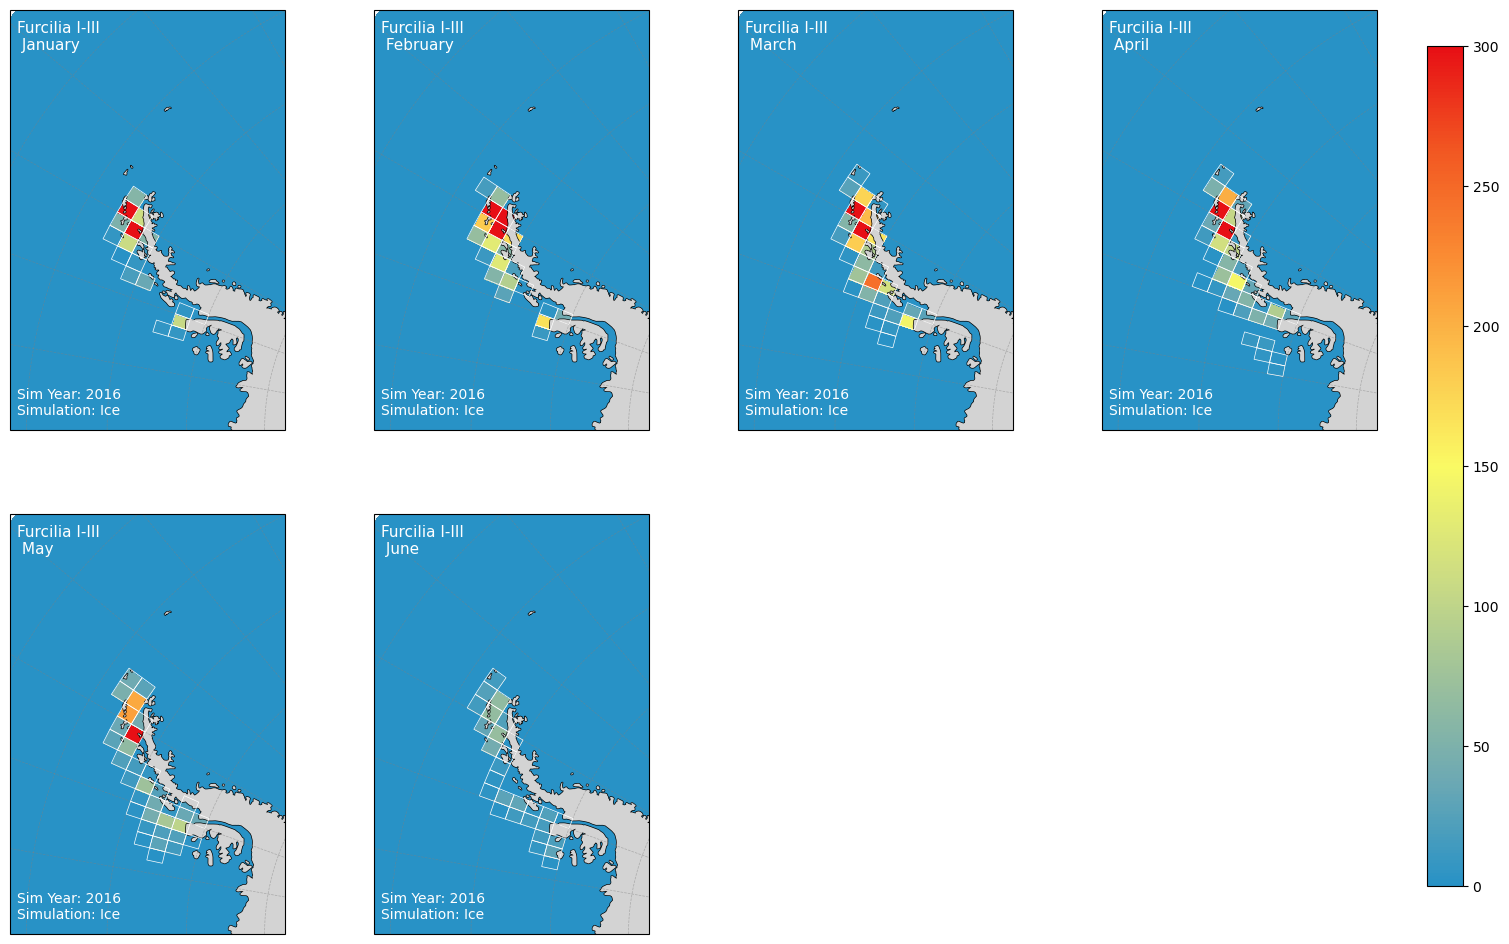

In [160]:
# Define parameters for preprocessing
SY = 2016
hyp = 'h_ice'
age = 3  # Change this as needed

# Define the grid extent and resolution (1° latitude by 2° longitude)
lat_min, lat_max = -75, -50
lon_min, lon_max = -90, 0
lat_resolution = 1  # 1 degree latitude resolution
lon_resolution = 2  # 2 degree longitude resolution
vmax=300

# lat_resolution = 0.5  # 1 degree latitude resolution
# lon_resolution = 1  # 2 degree longitude resolution
# vmax=150

# Create latitude and longitude bins for the coarse grid
lat_bins = np.arange(lat_min, lat_max + lat_resolution, lat_resolution)
lon_bins = np.arange(lon_min, lon_max + lon_resolution, lon_resolution)

# Step 2: Preprocess the data and generate heatmaps for each month
monthly_heatmaps = preprocess_data(df_traj, start_year=SY, hypothesis=hyp, stage=age, lat_bins=lat_bins, lon_bins=lon_bins)

# Step 3: Inspect the heatmaps before plotting
if not monthly_heatmaps:
    print("No heatmaps were generated. Something went wrong during preprocessing.")
else:
    print("Available heatmaps:", monthly_heatmaps.keys())


# Call the plotting function with the preprocessed data
plot_all_months(monthly_heatmaps, lat_bins, lon_bins, fig_path, SY, hyp, age, lat_resolution, lon_resolution, vmax, plot_config)

## Use smaller resolution: 0.5 ̊latitude by 1 ̊ longitude grid cells

In [27]:

# Define parameters for preprocessing
SY = 2018
hyp = 'h_ice'
age = 3  # Stage (1 or 2)

# Define the grid extent and resolution (1° latitude by 2° longitude)
lat_min, lat_max = -75, -50
lon_min, lon_max = -90, 0
lat_resolution = .5  # .5 degree latitude resolution
lon_resolution = 1  # 2 degree longitude resolution

# Create latitude and longitude bins for the coarse grid
lat_bins = np.arange(lat_min, lat_max + lat_resolution, lat_resolution)
lon_bins = np.arange(lon_min, lon_max + lon_resolution, lon_resolution)

# Step 2: Preprocess the data and generate heatmaps for each month
monthly_heatmaps = preprocess_data(df_traj, start_year=SY, hypothesis=hyp, stage=age, lat_bins=lat_bins, lon_bins=lon_bins)

# Step 3: Inspect the heatmaps before plotting
if not monthly_heatmaps:
    print("No heatmaps were generated. Something went wrong during preprocessing.")
else:
    print("Available heatmaps:", monthly_heatmaps.keys())


Processing month 1 with 613 data points
Processing month 2 with 1134 data points
Processing month 3 with 1571 data points
Processing month 4 with 1622 data points
Processing month 5 with 2078 data points
Processing month 6 with 902 data points
Available heatmaps: dict_keys([1, 2, 3, 4, 5, 6])


In [28]:
# Step 4: Plot the heatmap for each month with your formatting
def plot_heatmap(coarse_heatmap_xr, coarse_heatmap, month, lat_bins, lon_bins, fig_path, SY, hyp, age):
    # Step 7: Plot the coarse grid heatmap over the base map
    fig, ax = plt.subplots(figsize=(10, 6), subplot_kw={'projection': ccrs.SouthPolarStereo()})
    extent = [-85, -49, -72, -59]  # Adjust extent to -180 to 180 longitude format

    # Plot the base map with the region
    plot_region(ax, extent)

    # Set color scale limits for heatmap
    vmin = 0  # Minimum value
    vmax = 200  # Adjust based on your data

    # Overlay the heatmap using pcolormesh for proper alignment with lat/lon
    heatmap_plot = coarse_heatmap_xr.plot.pcolormesh(ax=ax, cmap=perry_cmap, #cmap='viridis',
                                                     transform=ccrs.PlateCarree(),
                                                     vmin=vmin, vmax=vmax,
                                                     add_colorbar=True)

    # Outline grid cells where the values are greater than zero
    for lat_idx in range(len(lat_bins) - 1):
        for lon_idx in range(len(lon_bins) - 1):
            if coarse_heatmap[lat_idx, lon_idx] > 0:  # Only outline non-zero cells
                # Get the corners of the grid cell
                lon_start = lon_bins[lon_idx]
                lon_end = lon_bins[lon_idx + 1]
                lat_start = lat_bins[lat_idx]
                lat_end = lat_bins[lat_idx + 1]
                
                # Create a rectangle patch for the grid cell
                rect = Rectangle((lon_start, lat_start), lon_end - lon_start, lat_end - lat_start,
                                 linewidth=0.5, edgecolor='white', facecolor='none', zorder=3, 
                                 transform=ccrs.PlateCarree())  # Ensure it's added in lat/lon coordinates
                ax.add_patch(rect)

    # Add annotation text
    ax.text(0.3, 0.025,  # Coordinates in figure space (x, y)
        f"{lat_resolution}° Lat by {lon_resolution}° Lon Grid", 
        transform=ax.transAxes,  # Use axis coordinates for positioning
        ha='center', va='center', fontsize=8, color='white')

    # Add title
    plt.title(f'Stage {age} Distribution for Month {month} ({SY})')

    # Save the plot before showing it
    save_path = f'{fig_path}/smaller_grid_stage{age}_month{month}_year{SY}_{hyp}.png'
    plt.savefig(save_path, dpi=300, bbox_inches='tight')  # Save as a PNG with 300 DPI

    plt.show()


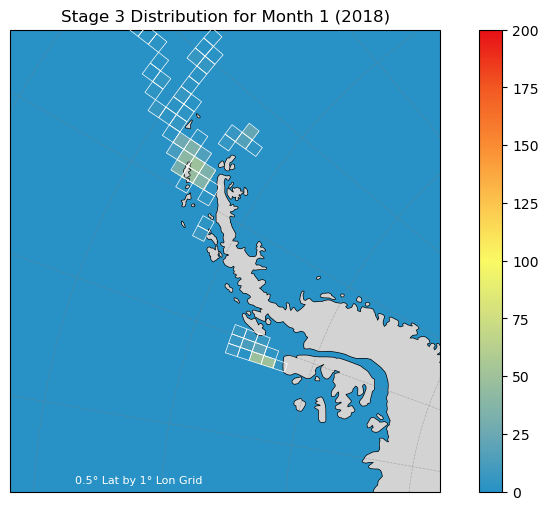

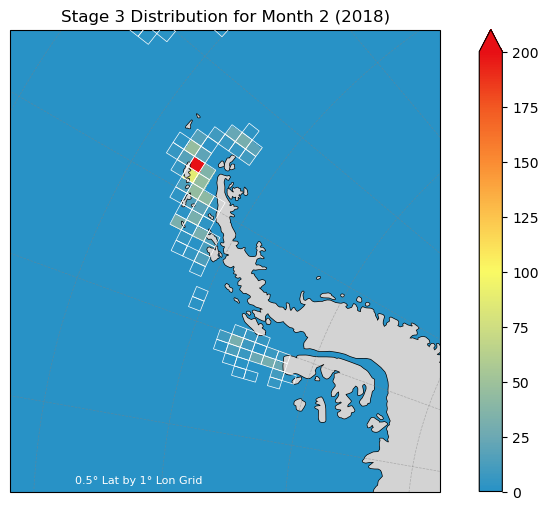

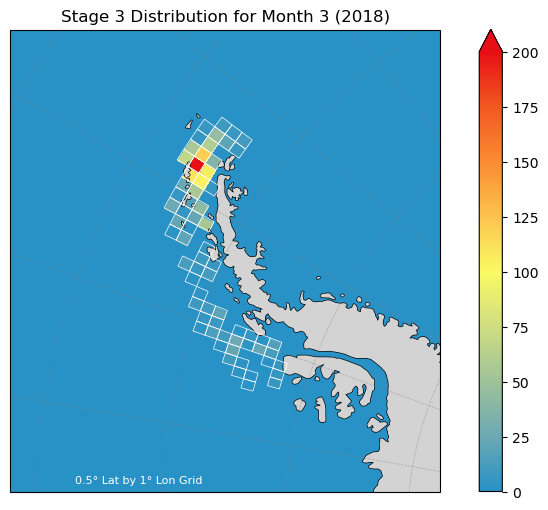

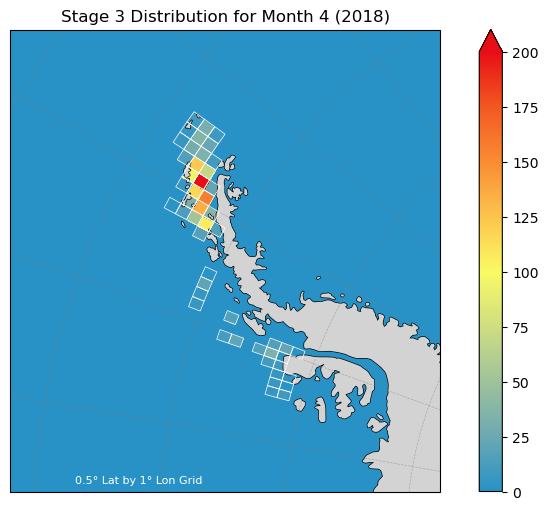

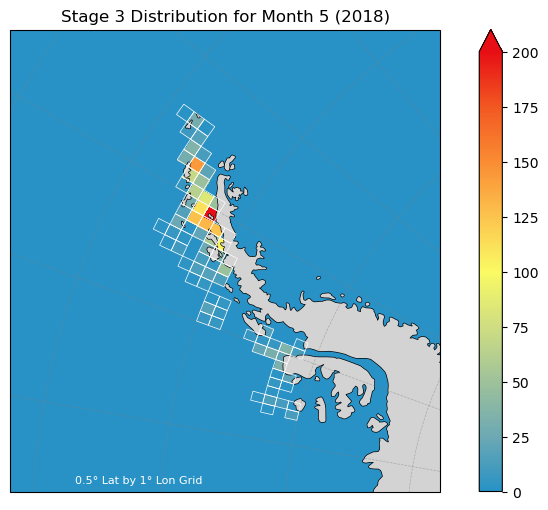

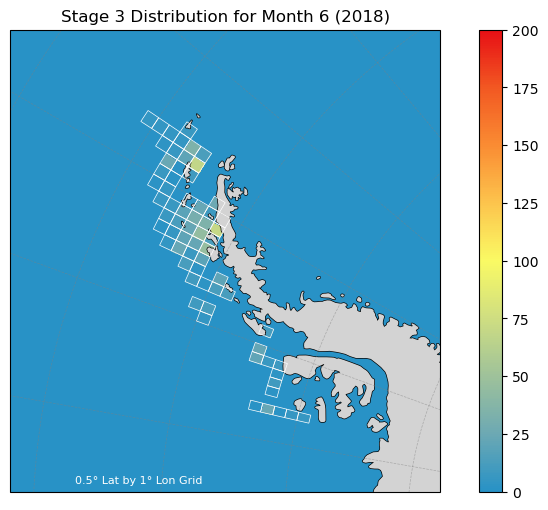

In [29]:
# Step 5: Loop through each month and plot with formatting
for month, heatmap in monthly_heatmaps.items():
    # Convert heatmap to xarray for plotting
    coarse_heatmap_xr = xr.DataArray(
        heatmap,
        coords=[('latitude', (lat_bins[:-1] + lat_bins[1:]) / 2),  # Midpoints of latitude bins
                ('longitude', (lon_bins[:-1] + lon_bins[1:]) / 2)],  # Midpoints of longitude bins
        dims=['latitude', 'longitude']
    )
    
    # Plot the heatmap for this month
    plot_heatmap(coarse_heatmap_xr, heatmap, month, lat_bins, lon_bins, fig_path, SY, hyp, age)